In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Improve plot appearance
sns.set_style("whitegrid")
# Load the dataset
df = pd.read_csv(r"C:\Users\udayk\OneDrive\Desktop\OptiCrop\Crop_recommendation.csv")

# Display the first five rows
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (2200, 8)


In [5]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [6]:
# Check for missing values# 
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [7]:
# Check for duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
# Summary statistics
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [10]:
# Count each crop
df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [11]:
print("Number of Crop Types:", df["label"].nunique())

Number of Crop Types: 22


In [12]:
df.info()

df.isnull().sum()

df.duplicated().sum()

df.describe()

df["label"].value_counts()

df["label"].nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


22

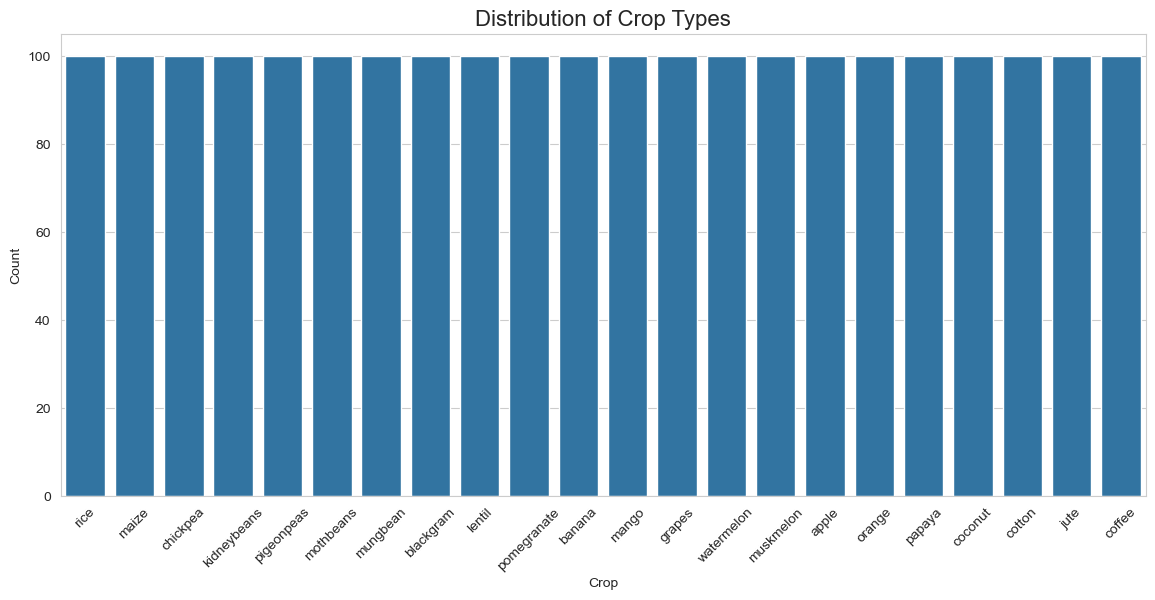

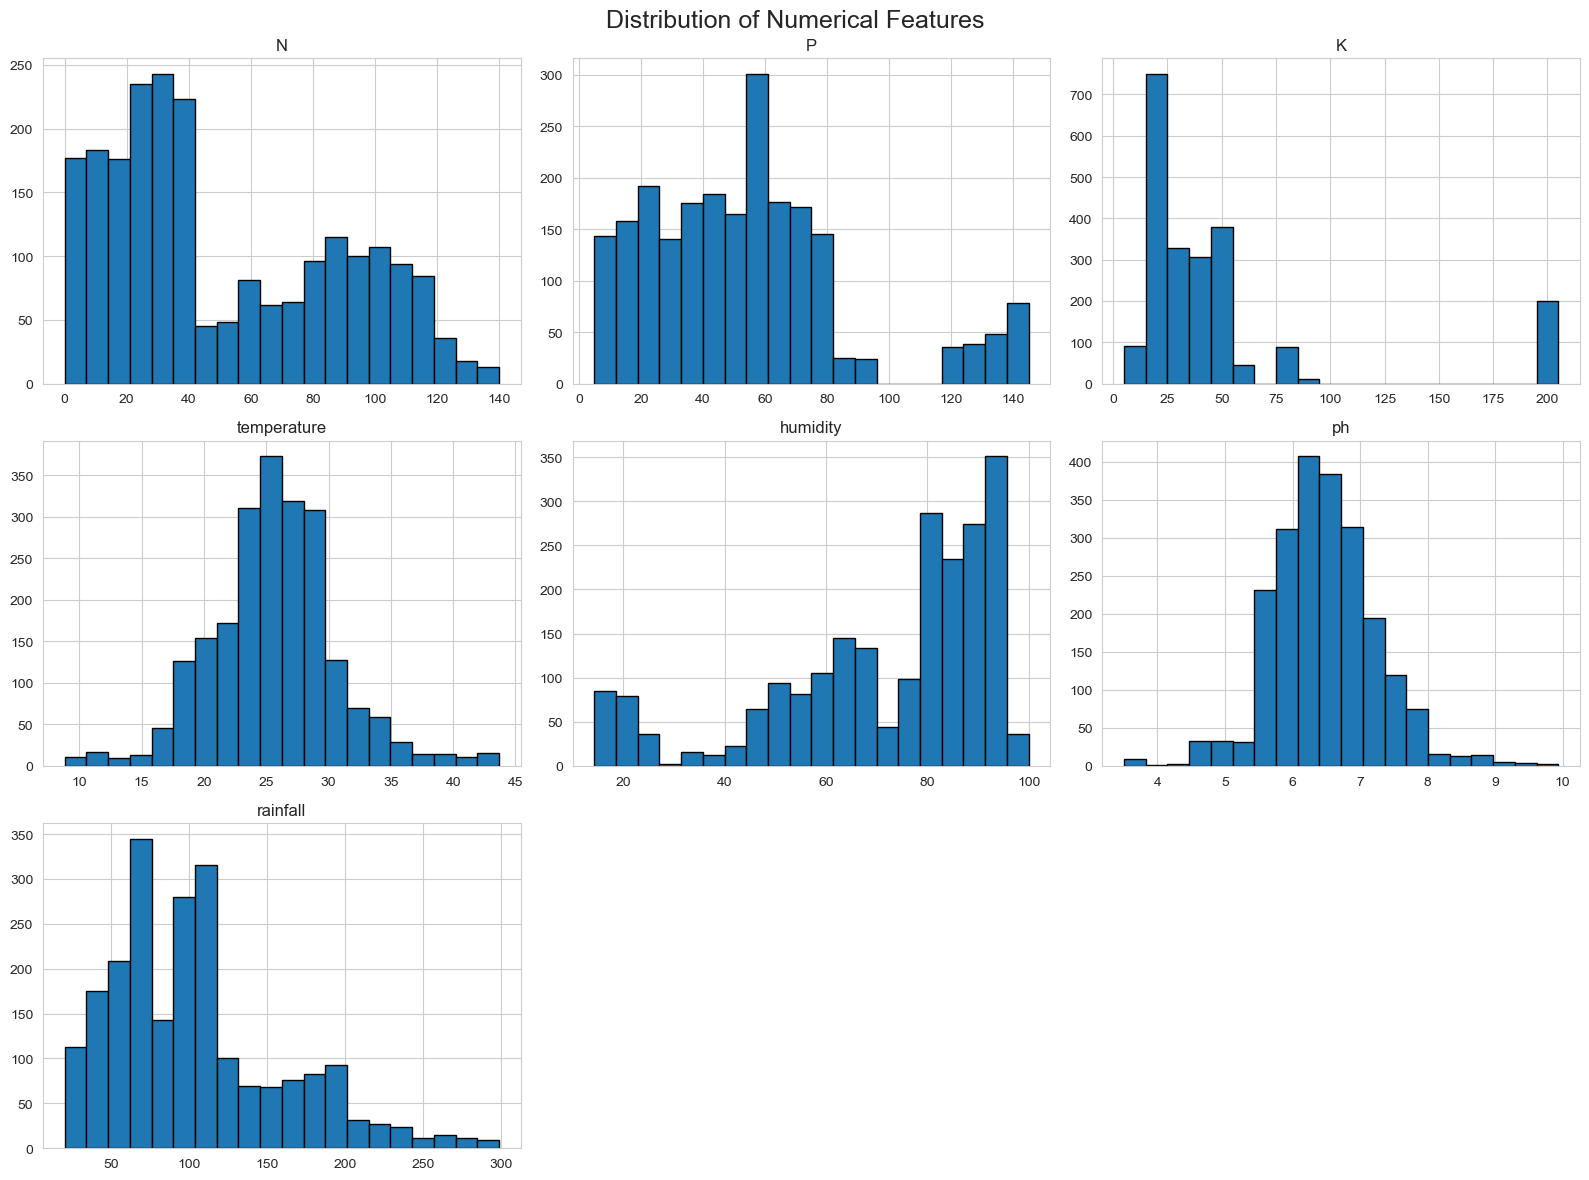

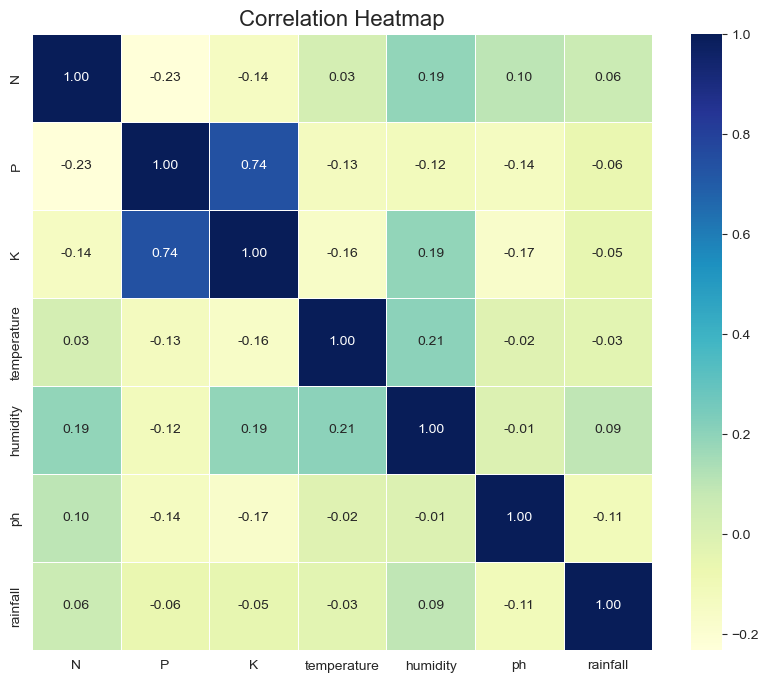

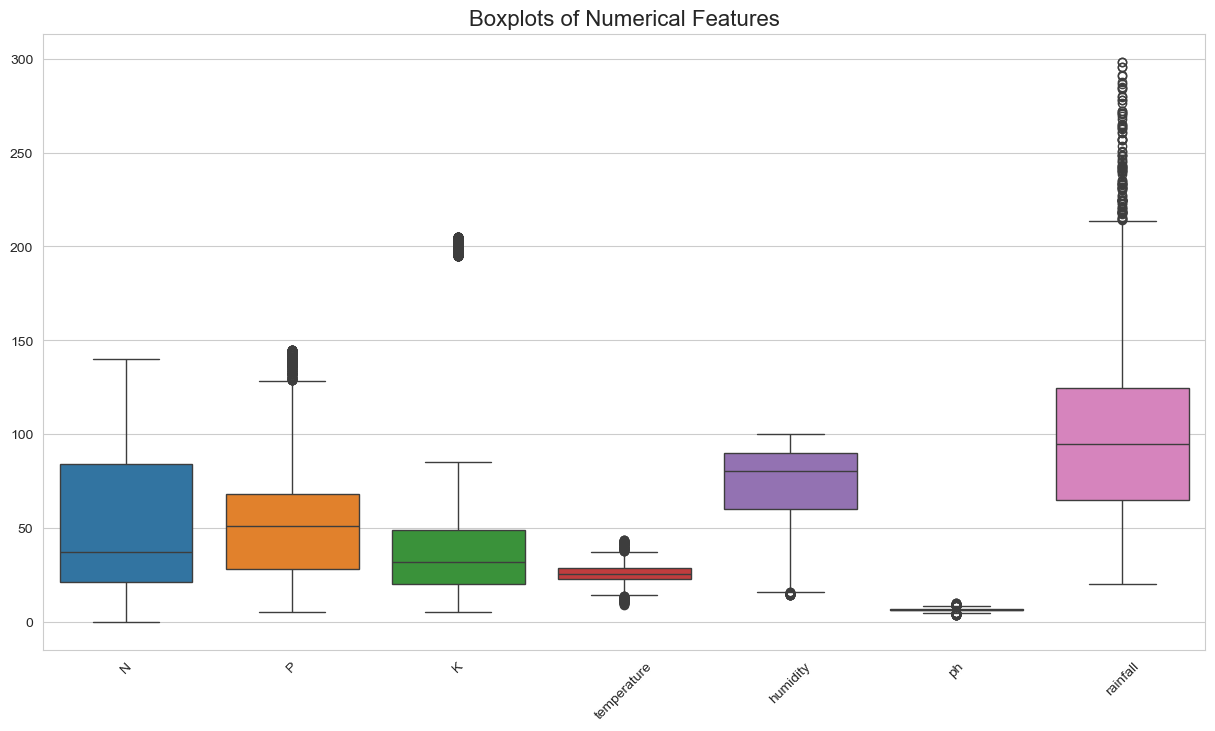

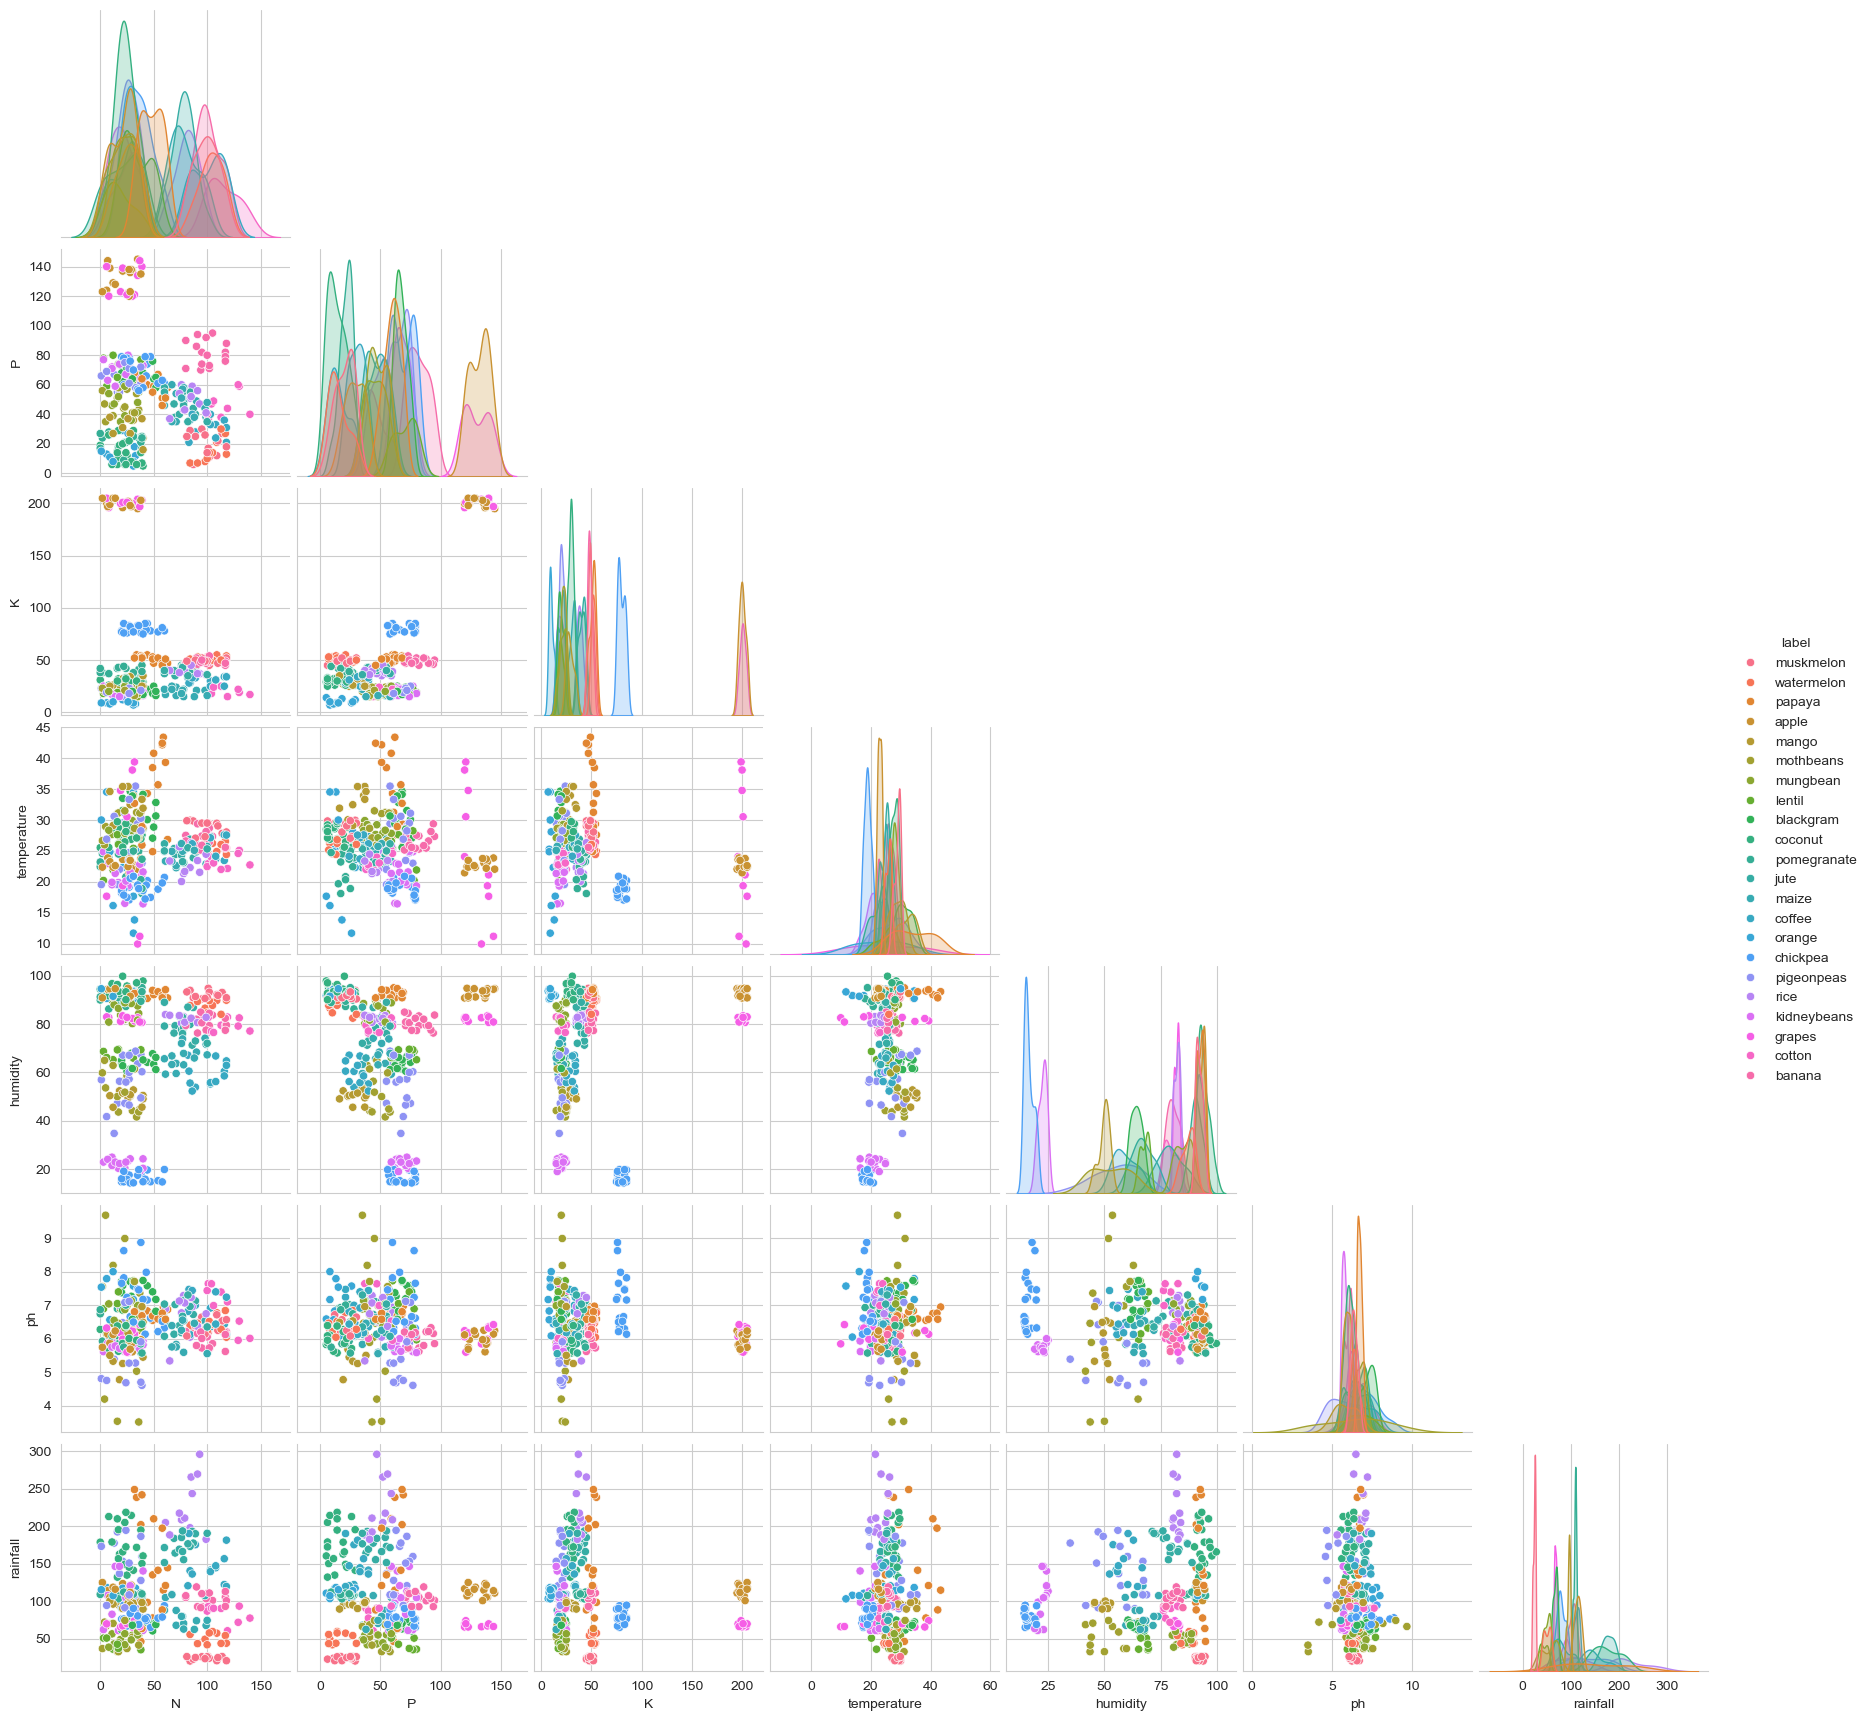

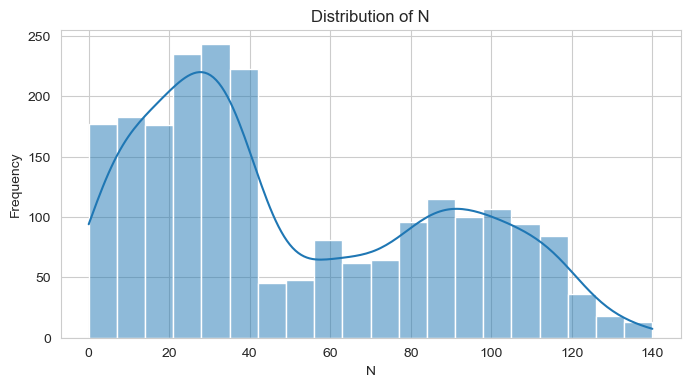

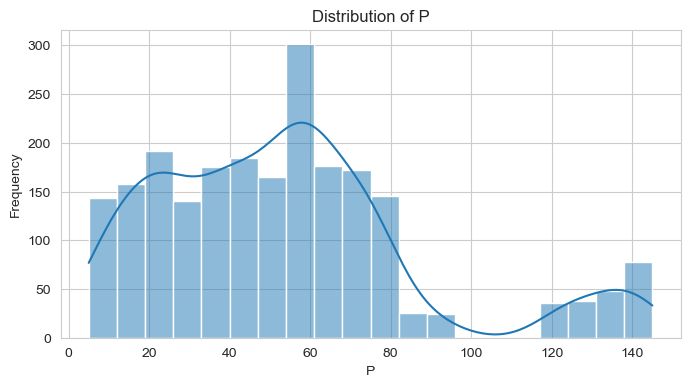

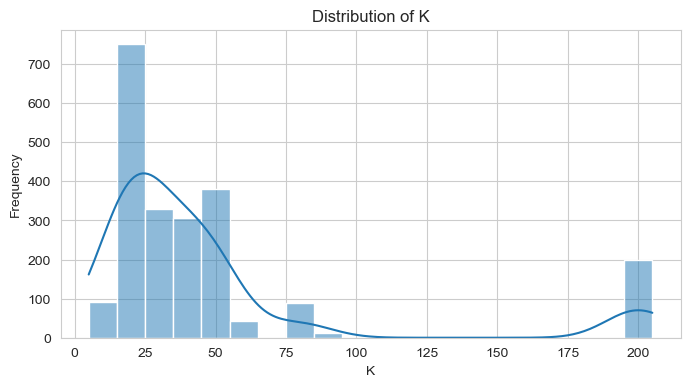

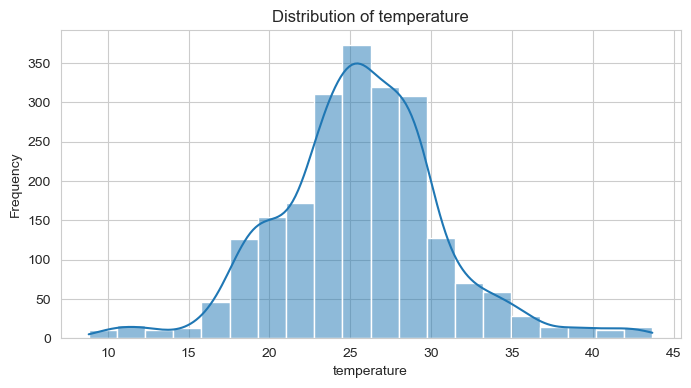

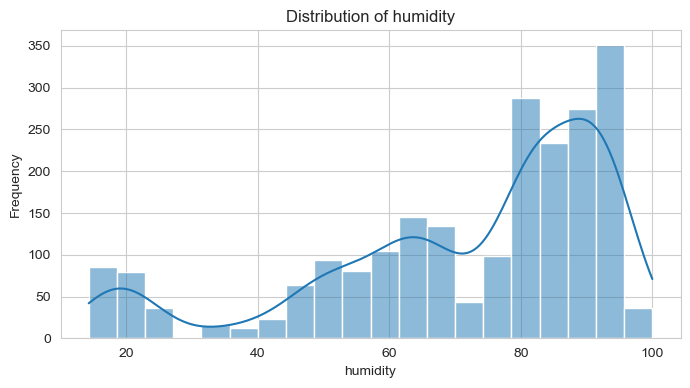

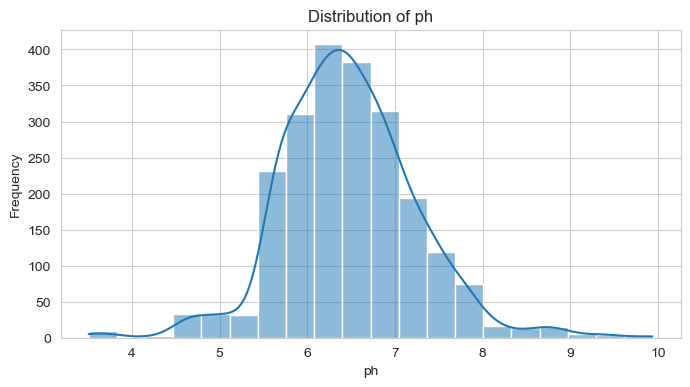

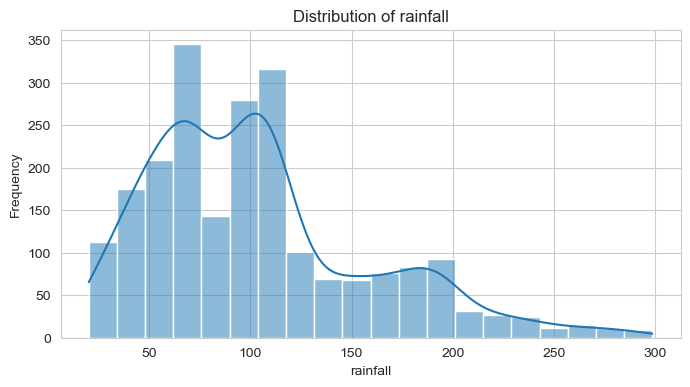

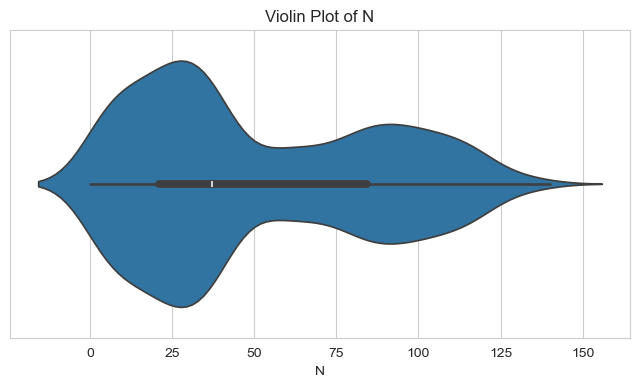

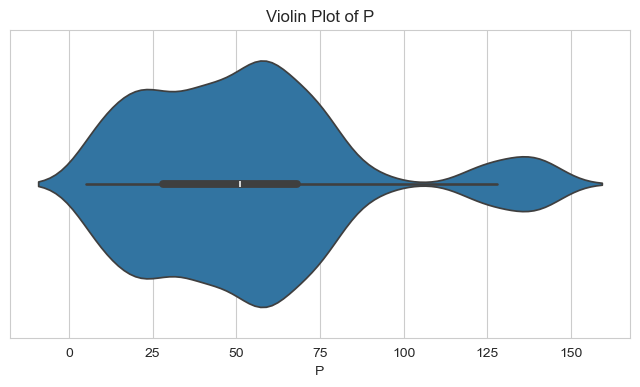

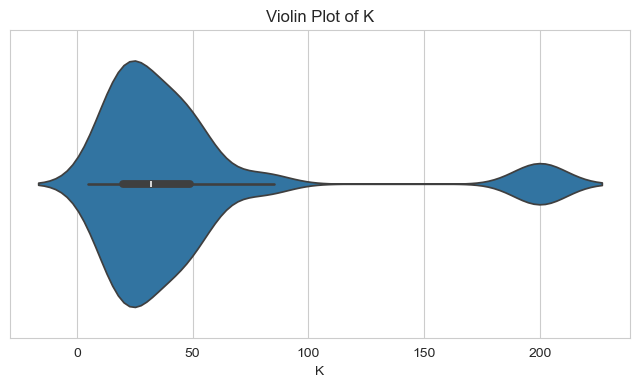

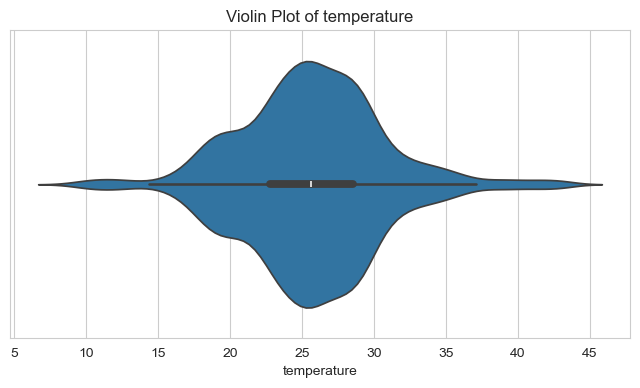

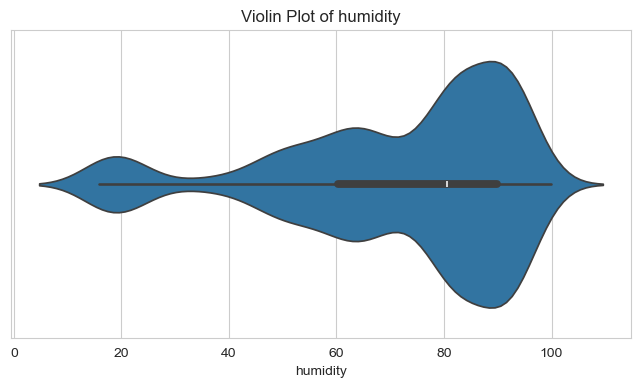

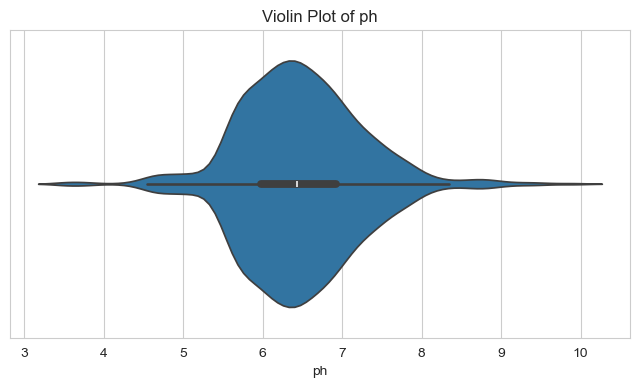

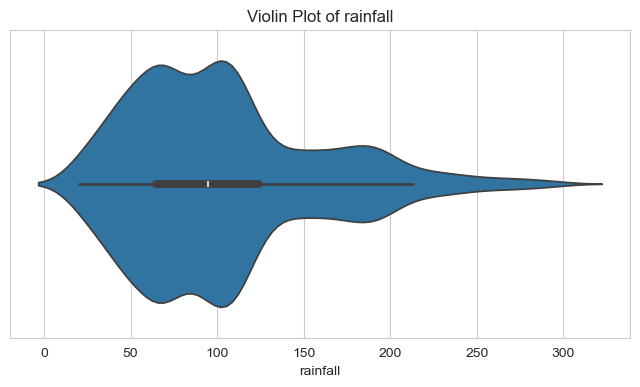

Correlation Matrix
                    N         P         K  temperature  humidity        ph  \
N            1.000000 -0.231460 -0.140512     0.026504  0.190688  0.096683   
P           -0.231460  1.000000  0.736232    -0.127541 -0.118734 -0.138019   
K           -0.140512  0.736232  1.000000    -0.160387  0.190859 -0.169503   
temperature  0.026504 -0.127541 -0.160387     1.000000  0.205320 -0.017795   
humidity     0.190688 -0.118734  0.190859     0.205320  1.000000 -0.008483   
ph           0.096683 -0.138019 -0.169503    -0.017795 -0.008483  1.000000   
rainfall     0.059020 -0.063839 -0.053461    -0.030084  0.094423 -0.109069   

             rainfall  
N            0.059020  
P           -0.063839  
K           -0.053461  
temperature -0.030084  
humidity     0.094423  
ph          -0.109069  
rainfall     1.000000  
Crop Distribution
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgr

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


Missing Values
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
Duplicate Records
0

EDA Completed Successfully ✅


In [13]:
# ==========================================
# DATA VISUALIZATION (EDA)
# Smart Agricultural Production Optimization Engine
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")

# --------------------------------------------------
# 1. Crop Distribution
# --------------------------------------------------

plt.figure(figsize=(14,6))
sns.countplot(x='label', data=df, order=df['label'].value_counts().index)

plt.title("Distribution of Crop Types", fontsize=16)
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()


# --------------------------------------------------
# 2. Histograms of Numerical Features
# --------------------------------------------------

df.hist(
    figsize=(16,12),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Features", fontsize=18)

plt.tight_layout()

plt.show()


# --------------------------------------------------
# 3. Correlation Heatmap
# --------------------------------------------------

plt.figure(figsize=(10,8))

corr = df.drop("label", axis=1).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=16)

plt.show()


# --------------------------------------------------
# 4. Boxplots for Outlier Detection
# --------------------------------------------------

plt.figure(figsize=(15,8))

sns.boxplot(data=df.drop("label", axis=1))

plt.title("Boxplots of Numerical Features", fontsize=16)

plt.xticks(rotation=45)

plt.show()


# --------------------------------------------------
# 5. Pairplot
# (Shows relationships between numerical features)
# --------------------------------------------------

sample_df = df.sample(300, random_state=42)

sns.pairplot(
    sample_df,
    hue="label",
    corner=True
)

plt.show()


# --------------------------------------------------
# 6. Distribution Plot for Each Feature
# --------------------------------------------------

features = ['N','P','K','temperature','humidity','ph','rainfall']

for feature in features:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[feature],
        kde=True,
        bins=20
    )

    plt.title(f"Distribution of {feature}")

    plt.xlabel(feature)

    plt.ylabel("Frequency")

    plt.show()


# --------------------------------------------------
# 7. Violin Plots
# --------------------------------------------------

for feature in features:

    plt.figure(figsize=(8,4))

    sns.violinplot(x=df[feature])

    plt.title(f"Violin Plot of {feature}")

    plt.show()


# --------------------------------------------------
# 8. Correlation Matrix (Numerical Values)
# --------------------------------------------------

print("="*60)
print("Correlation Matrix")
print("="*60)

print(df.drop("label", axis=1).corr())


# --------------------------------------------------
# 9. Crop Count
# --------------------------------------------------

print("="*60)
print("Crop Distribution")
print("="*60)

print(df["label"].value_counts())


# --------------------------------------------------
# 10. Number of Crop Classes
# --------------------------------------------------

print("="*60)
print("Total Crop Classes")
print("="*60)

print(df["label"].nunique())


# --------------------------------------------------
# 11. Summary Statistics
# --------------------------------------------------

print("="*60)
print("Statistical Summary")
print("="*60)

display(df.describe())


# --------------------------------------------------
# 12. Missing Values
# --------------------------------------------------

print("="*60)
print("Missing Values")
print("="*60)

print(df.isnull().sum())


# --------------------------------------------------
# 13. Duplicate Records
# --------------------------------------------------

print("="*60)
print("Duplicate Records")
print("="*60)

print(df.duplicated().sum())


# --------------------------------------------------
# END OF EDA
# --------------------------------------------------

print("\nEDA Completed Successfully ✅")